<a href="https://colab.research.google.com/github/Math-BUG/INF-494/blob/main/04_dbscan_nvcc_multi_eps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN CUDA C++/NVCC - Multi-EPS experimental

Este notebook usa o protocolo comum de `data/manifest.csv` e calcula tres valores de `eps` na mesma execucao CUDA: `eps_baixo`, `eps_base` e `eps_alto`.

Multi-EPS nao e a principal tentativa de ganhar do `cuML` em um unico `eps`. A proposta e ser util quando o usuario precisa avaliar varios valores de `eps`, reaproveitando leitura e calculo de distancia. A versao ainda e didatica, `O(n^2)`, sem indice espacial e sem combinacao com drop de core points.

As medicoes usam warm-up, `N_REPEATS = 3` e mediana dos tempos.

In [1]:
# Diagnostico do ambiente do Colab.
# Ative GPU em: Ambiente de execucao > Alterar tipo de ambiente de execucao > GPU.
!nvidia-smi
!nvcc --version
!which nvprof || echo "nvprof nao encontrado"

Mon Jun  8 07:31:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import re
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)

# Use Google Drive para persistir data/ e results/ entre notebooks e runtimes do Colab.
# Se nao estiver no Colab, o codigo cai automaticamente para o diretorio local.
USE_GOOGLE_DRIVE = True
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/INF494_DBSCAN")

BASE_DIR = Path(".")
if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        BASE_DIR = DRIVE_PROJECT_DIR
    except Exception as exc:
        print("Google Drive nao montado; usando diretorio local.")
        print("Motivo:", repr(exc))
        BASE_DIR = Path(".")

DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

HAS_CUML = False
cp = None
CuMLDBSCAN = None

try:
    import cupy as cp
    from cuml.cluster import DBSCAN as CuMLDBSCAN
    HAS_CUML = True
    print("RAPIDS/cuML disponivel. Baseline: cuML.")
except Exception as exc:
    print("RAPIDS/cuML nao disponivel. Alternativa do baseline: sklearn CPU.")
    print("Motivo:", repr(exc))

print("HAS_CUML:", HAS_CUML)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/INF494_DBSCAN
DATA_DIR: /content/drive/MyDrive/INF494_DBSCAN/data
RESULTS_DIR: /content/drive/MyDrive/INF494_DBSCAN/results
RAPIDS/cuML disponivel. Baseline: cuML.
HAS_CUML: True


In [3]:
def normalize_minmax(X):
    X = np.asarray(X, dtype=np.float32)
    mn = X.min(axis=0)
    mx = X.max(axis=0)
    denom = mx - mn
    denom[denom == 0.0] = 1.0
    return ((X - mn) / denom).astype(np.float32)


def estimate_eps(X, min_samples=8, quantile=0.90, sample_size=5000, seed=SEED):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    if len(X) > sample_size:
        idx = rng.choice(len(X), size=sample_size, replace=False)
        Xs = X[idx]
    else:
        Xs = X
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(Xs)
    dists, _ = nn.kneighbors(Xs)
    return float(np.quantile(dists[:, -1], quantile))


def relabel_consecutive(labels):
    labels = np.asarray(labels, dtype=np.int32)
    out = np.full(labels.shape, -1, dtype=np.int32)
    valid = [int(v) for v in np.unique(labels) if int(v) != -1]
    for new, old in enumerate(sorted(valid)):
        out[labels == old] = new
    return out


def count_clusters(labels):
    values = set(np.asarray(labels).tolist())
    values.discard(-1)
    return len(values)


def noise_percent(labels):
    return 100.0 * float(np.mean(np.asarray(labels) == -1))


def run_baseline_dbscan(X, eps, min_samples):
    X = np.ascontiguousarray(X.astype(np.float32))
    start = time.time()
    if HAS_CUML:
        X_gpu = cp.asarray(X)
        model = CuMLDBSCAN(eps=float(eps), min_samples=int(min_samples))
        labels_gpu = model.fit_predict(X_gpu)
        cp.cuda.Stream.null.synchronize()
        labels = cp.asnumpy(labels_gpu).astype(np.int32)
        backend = "cuML"
    else:
        model = SklearnDBSCAN(eps=float(eps), min_samples=int(min_samples), n_jobs=-1)
        labels = model.fit_predict(X).astype(np.int32)
        backend = "sklearn_cpu"
    elapsed = time.time() - start
    return relabel_consecutive(labels), elapsed, backend


def parse_key_values_stdout(stdout):
    metrics = {}
    for key, value in re.findall(r"([A-Za-z0-9_]+)=([^\s]+)", stdout):
        clean = value.strip().rstrip(",")
        try:
            if re.fullmatch(r"[-+]?\d+", clean):
                metrics[key] = int(clean)
            else:
                metrics[key] = float(clean)
        except ValueError:
            metrics[key] = clean
    return metrics


def run_cuda_binary(cmd):
    start = time.time()
    completed = subprocess.run(cmd, check=True, capture_output=True, text=True)
    wall_time = time.time() - start
    return completed.stdout, wall_time


def print_table(df, title):
    print(title)
    print(df.where(pd.notna(df), "N/A").to_string(index=False))


def plot_2d(X, labels, title):
    if X.shape[1] == 2:
        X2 = X[:, :2]
        xlab, ylab = "x1", "x2"
    else:
        X2 = PCA(n_components=2, random_state=SEED).fit_transform(X)
        xlab, ylab = "PCA1", "PCA2"
    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=8, cmap="tab20", alpha=0.85, linewidths=0)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.tight_layout()
    plt.show()

def make_controlled_dataset(name, n_samples, seed=SEED, n_features_32d=32):
    rng = np.random.default_rng(seed)
    if name == "dense_blobs_2d":
        X, y = make_blobs(n_samples=n_samples, centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)], cluster_std=0.18, random_state=seed)
    elif name == "heterogeneous_blobs_2d":
        n1 = int(0.45 * n_samples)
        n2 = int(0.35 * n_samples)
        n3 = n_samples - n1 - n2
        X1, _ = make_blobs(n_samples=n1, centers=[(-4, 0)], cluster_std=0.08, random_state=seed + 1)
        X2, _ = make_blobs(n_samples=n2, centers=[(0, 0)], cluster_std=0.25, random_state=seed + 2)
        X3, _ = make_blobs(n_samples=n3, centers=[(4, 0)], cluster_std=0.65, random_state=seed + 3)
        X = np.vstack([X1, X2, X3])
        y = np.concatenate([np.zeros(n1, dtype=np.int32), np.ones(n2, dtype=np.int32), np.full(n3, 2, dtype=np.int32)])
    elif name == "dense_blobs_noise_2d":
        n_noise = int(0.20 * n_samples)
        n_blob = n_samples - n_noise
        X_blob, y_blob = make_blobs(n_samples=n_blob, centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)], cluster_std=0.20, random_state=seed)
        noise = rng.uniform(low=-5.5, high=5.5, size=(n_noise, 2))
        X = np.vstack([X_blob, noise])
        y = np.concatenate([y_blob.astype(np.int32), np.full(n_noise, -1, dtype=np.int32)])
    elif name == "moons_2d":
        X, y = make_moons(n_samples=n_samples, noise=0.045, random_state=seed)
    elif name == "blobs_32d":
        X, y = make_blobs(n_samples=n_samples, centers=6, n_features=n_features_32d, cluster_std=0.45, random_state=seed)
    else:
        raise ValueError(f"Fallback local so cobre datasets sinteticos. Dataset recebido: {name}")
    return normalize_minmax(X), np.asarray(y, dtype=np.int32)


def load_dataset_from_manifest(dataset_name, n_samples, run_mode="benchmark", allow_local_debug_fallback=True):
    manifest_path = DATA_DIR / "manifest.csv"
    if manifest_path.exists():
        manifest = pd.read_csv(manifest_path)
        rows = manifest[(manifest["dataset_name"] == dataset_name) & (manifest["n_samples"] == int(n_samples))]
        if rows.empty:
            available = manifest[["dataset_name", "n_samples"]].drop_duplicates().to_string(index=False)
            raise ValueError(
                f"Dataset {dataset_name} com n_samples={n_samples} nao esta no manifest. "
                f"Execute o notebook 00 ou escolha uma entrada existente.\nEntradas disponiveis:\n{available}"
            )
        row = rows.iloc[0].to_dict()
        data_path = Path(row["data_path"])
        label_path = Path(row["label_path"])
        if not data_path.exists() or not label_path.exists():
            raise FileNotFoundError(
                f"Arquivos do dataset nao encontrados: {data_path} / {label_path}. "
                "Execute primeiro o notebook 00_datasets_e_configuracao.ipynb no Colab."
            )
        n = int(row["n_samples"])
        d = int(row["n_features"])
        X = np.fromfile(data_path, dtype=np.float32).reshape(n, d)
        y_true = np.load(label_path).astype(np.int32)
        return {
            "X": np.ascontiguousarray(X),
            "y_true": y_true,
            "EPS": float(row["eps"]),
            "MIN_SAMPLES": int(row["min_samples"]),
            "INPUT_BIN": str(data_path),
            "N": n,
            "D": d,
            "metadata": row,
            "loaded_from_manifest": True,
        }

    message = (
        "data/manifest.csv nao encontrado. Execute primeiro o notebook "
        "00_datasets_e_configuracao.ipynb para gerar datasets comuns."
    )
    if not allow_local_debug_fallback:
        raise FileNotFoundError(message)
    print(message)
    print("Usando fallback local apenas para depuracao. Resultados finais devem usar o manifest comum.")
    fallback_n = 4000 if run_mode == "quick" else min(int(n_samples), 4000)
    X, y_true = make_controlled_dataset(dataset_name, fallback_n)
    X = np.ascontiguousarray(X.astype(np.float32))
    eps = estimate_eps(X, min_samples=8, quantile=0.90, sample_size=5000)
    input_bin = f"debug_{dataset_name}_{fallback_n}_f32.bin"
    X.tofile(input_bin)
    return {
        "X": X,
        "y_true": y_true,
        "EPS": eps,
        "MIN_SAMPLES": 8,
        "INPUT_BIN": input_bin,
        "N": int(X.shape[0]),
        "D": int(X.shape[1]),
        "metadata": {
            "dataset_name": dataset_name,
            "n_samples": int(X.shape[0]),
            "n_features": int(X.shape[1]),
            "tipo": "debug_local",
            "observacao": "Fallback local; nao usar em resultado final.",
        },
        "loaded_from_manifest": False,
    }


def parse_multi_eps_stdout(stdout):
    metrics = parse_key_values_stdout(stdout)
    rows = {}
    pattern = r"eps_index=(\d+)\s+eps=([0-9.+-eE]+)\s+core_points=(\d+)\s+noise=(\d+)"
    for idx, eps, core_points, noise in re.findall(pattern, stdout):
        rows[int(idx)] = {"eps": float(eps), "core_points": int(core_points), "noise": int(noise)}
    return metrics, rows

In [4]:
# Celula padrao de selecao do dataset comum.
# Primeiro teste: mantenha RUN_MODE="quick" e N_SAMPLES=4000, que e o padrao gerado pelo notebook 00.
# Para resultados finais: rode o notebook 00 em RUN_MODE="benchmark" e depois use N_SAMPLES=10000/25000/50000 aqui.
DATASET_NAME = "heterogeneous_blobs_2d"
N_SAMPLES = 4000
RUN_MODE = "quick"  # use "benchmark" e N_SAMPLES = 10000 depois de gerar o manifest benchmark no notebook 00
ALLOW_LOCAL_DEBUG_FALLBACK = True

print("Datasets recomendados para este notebook:", ['heterogeneous_blobs_2d', 'real_covtype_sample'])

loaded = load_dataset_from_manifest(
    DATASET_NAME,
    N_SAMPLES,
    run_mode=RUN_MODE,
    allow_local_debug_fallback=ALLOW_LOCAL_DEBUG_FALLBACK,
)

X = loaded["X"]
y_true = loaded["y_true"]
EPS = loaded["EPS"]
MIN_SAMPLES = loaded["MIN_SAMPLES"]
INPUT_BIN = loaded["INPUT_BIN"]
N = loaded["N"]
D = loaded["D"]
META = loaded["metadata"]

print("Dataset ativo:", DATASET_NAME)
print("Carregado do manifest:", loaded["loaded_from_manifest"])
print("Shape:", X.shape)
print("eps:", EPS)
print("min_samples:", MIN_SAMPLES)
print("INPUT_BIN:", INPUT_BIN)

Datasets recomendados para este notebook: ['heterogeneous_blobs_2d', 'real_covtype_sample']
Dataset ativo: heterogeneous_blobs_2d
Carregado do manifest: True
Shape: (4000, 2)
eps: 0.0194469732363999
min_samples: 8
INPUT_BIN: /content/drive/MyDrive/INF494_DBSCAN/data/heterogeneous_blobs_2d_4000_f32.bin


In [5]:
EPS_BASE = EPS
EPS_NAMES = ["eps_baixo", "eps_base", "eps_alto"]
EPS_VALUES = np.array([0.75 * EPS_BASE, EPS_BASE, 1.25 * EPS_BASE], dtype=np.float32)
EPS0, EPS1, EPS2 = [float(v) for v in EPS_VALUES]
print("EPS_VALUES:", dict(zip(EPS_NAMES, EPS_VALUES)))

EPS_VALUES: {'eps_baixo': np.float32(0.01458523), 'eps_base': np.float32(0.019446973), 'eps_alto': np.float32(0.024308717)}


In [6]:
%%writefile dbscan_multi_eps.cu
#include <stdio.h>
#include <stdlib.h>
#include <stdint.h>
#include <math.h>
#include <fstream>
#include <vector>
#include <string>

#define NUM_EPS 3

#define CUDA_CHECK(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

__device__ int find_root_eps(int* parent, int base, int i) {
    int root = i;
    while (root != parent[base + root]) root = parent[base + root];
    return root;
}

__global__ void find_cores_multi_eps(
    const float* X,
    const float* eps_sq,
    int* is_core,
    int* neighbor_counts,
    int n,
    int d,
    int min_pts
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    int counts[NUM_EPS];
    #pragma unroll
    for (int e = 0; e < NUM_EPS; e++) counts[e] = 0;

    for (int j = 0; j < n; j++) {
        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq[NUM_EPS - 1]) break;
        }

        #pragma unroll
        for (int e = 0; e < NUM_EPS; e++) {
            if (dist_sq <= eps_sq[e]) counts[e]++;
        }

        int all_core = 1;
        #pragma unroll
        for (int e = 0; e < NUM_EPS; e++) {
            if (counts[e] < min_pts) all_core = 0;
        }
        if (all_core) break;
    }

    #pragma unroll
    for (int e = 0; e < NUM_EPS; e++) {
        int idx = e * n + i;
        neighbor_counts[idx] = counts[e];
        is_core[idx] = (counts[e] >= min_pts) ? 1 : 0;
    }
}

__global__ void init_parents_multi_eps(const int* is_core, int* parent, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int total = NUM_EPS * n;
    if (idx >= total) return;
    int i = idx % n;
    parent[idx] = i;
}

__global__ void connect_cores_multi_eps(
    const float* X,
    const float* eps_sq,
    const int* is_core,
    int* parent,
    int n,
    int d
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    for (int j = i + 1; j < n; j++) {
        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq[NUM_EPS - 1]) break;
        }

        #pragma unroll
        for (int e = 0; e < NUM_EPS; e++) {
            int base = e * n;
            if (dist_sq <= eps_sq[e] && is_core[base + i] && is_core[base + j]) {
                int root_i = find_root_eps(parent, base, i);
                int root_j = find_root_eps(parent, base, j);
                while (root_i != root_j) {
                    if (root_i < root_j) {
                        int old = atomicCAS(&parent[base + root_j], root_j, root_i);
                        if (old == root_j) break;
                        root_j = find_root_eps(parent, base, old);
                    } else {
                        int old = atomicCAS(&parent[base + root_i], root_i, root_j);
                        if (old == root_i) break;
                        root_i = find_root_eps(parent, base, old);
                    }
                }
            }
        }
    }
}

__global__ void flatten_multi_eps(int* parent, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int total = NUM_EPS * n;
    if (idx >= total) return;
    int e = idx / n;
    int i = idx % n;
    int base = e * n;
    int root = i;
    while (root != parent[base + root]) root = parent[base + root];
    parent[base + i] = root;
}

__global__ void assign_borders_multi_eps(
    const float* X,
    const float* eps_sq,
    const int* is_core,
    const int* parent,
    int* labels,
    int n,
    int d
) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int total = NUM_EPS * n;
    if (idx >= total) return;

    int e = idx / n;
    int i = idx % n;
    int base = e * n;

    if (is_core[base + i]) {
        labels[base + i] = parent[base + i];
        return;
    }

    int best_label = -1;
    float best_dist_sq = eps_sq[e];
    int found = 0;

    for (int j = 0; j < n; j++) {
        if (!is_core[base + j]) continue;

        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq[e]) break;
        }

        if (dist_sq <= eps_sq[e] && (!found || dist_sq < best_dist_sq)) {
            found = 1;
            best_dist_sq = dist_sq;
            best_label = parent[base + j];
        }
    }
    labels[base + i] = best_label;
}

int main(int argc, char** argv) {
    if (argc < 10) {
        printf("Usage: %s input.bin output_labels.bin n d eps0 eps1 eps2 min_pts output_counts.bin\n", argv[0]);
        return 1;
    }

    std::string input_path = argv[1];
    std::string output_labels_path = argv[2];
    int n = atoi(argv[3]);
    int d = atoi(argv[4]);
    float h_eps[NUM_EPS];
    h_eps[0] = (float)atof(argv[5]);
    h_eps[1] = (float)atof(argv[6]);
    h_eps[2] = (float)atof(argv[7]);
    int min_pts = atoi(argv[8]);
    std::string output_counts_path = argv[9];

    float h_eps_sq[NUM_EPS];
    for (int e = 0; e < NUM_EPS; e++) h_eps_sq[e] = h_eps[e] * h_eps[e];

    size_t data_count = (size_t)n * (size_t)d;
    std::vector<float> h_X(data_count);
    std::ifstream in(input_path, std::ios::binary);
    if (!in) { printf("Could not open input file.\n"); return 1; }
    in.read((char*)h_X.data(), data_count * sizeof(float));
    in.close();

    float* d_X = nullptr;
    float* d_eps_sq = nullptr;
    int *d_is_core = nullptr, *d_parent = nullptr, *d_labels = nullptr, *d_neighbor_counts = nullptr;
    CUDA_CHECK(cudaMalloc(&d_X, data_count * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_eps_sq, NUM_EPS * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_is_core, NUM_EPS * n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_parent, NUM_EPS * n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_labels, NUM_EPS * n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_neighbor_counts, NUM_EPS * n * sizeof(int)));

    CUDA_CHECK(cudaMemcpy(d_X, h_X.data(), data_count * sizeof(float), cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_eps_sq, h_eps_sq, NUM_EPS * sizeof(float), cudaMemcpyHostToDevice));

    int threads = 256;
    int blocks_n = (n + threads - 1) / threads;
    int blocks_multi = (NUM_EPS * n + threads - 1) / threads;

    cudaEvent_t e0, e1, e2, e3, e4, e5;
    cudaEventCreate(&e0); cudaEventCreate(&e1); cudaEventCreate(&e2);
    cudaEventCreate(&e3); cudaEventCreate(&e4); cudaEventCreate(&e5);

    cudaEventRecord(e0);
    find_cores_multi_eps<<<blocks_n, threads>>>(d_X, d_eps_sq, d_is_core, d_neighbor_counts, n, d, min_pts);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e1);

    init_parents_multi_eps<<<blocks_multi, threads>>>(d_is_core, d_parent, n);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e2);

    connect_cores_multi_eps<<<blocks_n, threads>>>(d_X, d_eps_sq, d_is_core, d_parent, n, d);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e3);

    flatten_multi_eps<<<blocks_multi, threads>>>(d_parent, n);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e4);

    assign_borders_multi_eps<<<blocks_multi, threads>>>(d_X, d_eps_sq, d_is_core, d_parent, d_labels, n, d);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e5);
    cudaEventSynchronize(e5);

    float ms_find=0, ms_init=0, ms_connect=0, ms_flatten=0, ms_assign=0;
    cudaEventElapsedTime(&ms_find, e0, e1);
    cudaEventElapsedTime(&ms_init, e1, e2);
    cudaEventElapsedTime(&ms_connect, e2, e3);
    cudaEventElapsedTime(&ms_flatten, e3, e4);
    cudaEventElapsedTime(&ms_assign, e4, e5);

    std::vector<int> h_labels(NUM_EPS * n);
    std::vector<int> h_counts(NUM_EPS * n);
    std::vector<int> h_core(NUM_EPS * n);
    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels, NUM_EPS * n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_counts.data(), d_neighbor_counts, NUM_EPS * n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_core.data(), d_is_core, NUM_EPS * n * sizeof(int), cudaMemcpyDeviceToHost));

    std::ofstream out_labels(output_labels_path, std::ios::binary);
    out_labels.write((char*)h_labels.data(), NUM_EPS * n * sizeof(int));
    out_labels.close();

    std::ofstream out_counts(output_counts_path, std::ios::binary);
    out_counts.write((char*)h_counts.data(), NUM_EPS * n * sizeof(int));
    out_counts.close();

    printf("n=%d d=%d min_pts=%d\n", n, d, min_pts);
    for (int e = 0; e < NUM_EPS; e++) {
        int base = e * n;
        int n_core = 0;
        int n_noise = 0;
        for (int i = 0; i < n; i++) {
            n_core += h_core[base + i];
            if (h_labels[base + i] == -1) n_noise++;
        }
        printf("eps_index=%d eps=%f core_points=%d noise=%d\n", e, h_eps[e], n_core, n_noise);
    }
    printf("time_find=%.6f time_init=%.6f time_connect=%.6f time_flatten=%.6f time_assign=%.6f total=%.6f seconds\n",
           ms_find/1000.0f, ms_init/1000.0f, ms_connect/1000.0f, ms_flatten/1000.0f, ms_assign/1000.0f,
           (ms_find + ms_init + ms_connect + ms_flatten + ms_assign)/1000.0f);

    cudaFree(d_X); cudaFree(d_eps_sq); cudaFree(d_is_core); cudaFree(d_parent); cudaFree(d_labels); cudaFree(d_neighbor_counts);
    return 0;
}

Writing dbscan_multi_eps.cu


In [7]:
!nvcc dbscan_multi_eps.cu -o dbscan_multi_eps -O3

!if command -v nvprof >/dev/null 2>&1; then nvprof ./dbscan_multi_eps {INPUT_BIN} nvprof_multi_eps_labels.bin {N} {D} {EPS0} {EPS1} {EPS2} {MIN_SAMPLES} nvprof_multi_eps_counts.bin; else echo "nvprof nao encontrado; executando binario diretamente"; ./dbscan_multi_eps {INPUT_BIN} nvprof_multi_eps_labels.bin {N} {D} {EPS0} {EPS1} {EPS2} {MIN_SAMPLES} nvprof_multi_eps_counts.bin; fi

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
==1553== NVPROF is profiling process 1553, command: ./dbscan_multi_eps /content/drive/MyDrive/INF494_DBSCAN/data/heterogeneous_blobs_2d_4000_f32.bin nvprof_multi_eps_labels.bin 4000 2 0.014585229568183422 0.019446972757577896 0.024308716878294945 8 nvprof_multi_eps_counts.bin
n=4000 d=2 min_pts=8
eps_index=0 eps=0.014585 core_points=3305 noise=499
eps_index=1 eps=0.019447 core_points=3600 noise=222
eps_index=2 eps=0.024309 core_points=3761 noise=150
time_find=0.155022 time_init=0.000026 time_connect=0.023761 time_flatten=0.000051 time_assign=0.001661 total=0.180521 seconds
==1553== Profiling application: ./dbscan_multi_eps /content/drive/MyDrive/INF494_DBSCAN/data/heterogeneous_blobs_2d_4000_f32.bin nvprof_multi_eps_labels.bin 4000 2 0.014585229568183422 0.019446972757577896 0.024308716878294945 8 nvpr

In [8]:
N_REPEATS = 3
WARMUP_N = min(2000, N)

print("Warm-up baseline e CUDA em amostra:", WARMUP_N)
_ = run_baseline_dbscan(X[:WARMUP_N], float(EPS_VALUES[1]), MIN_SAMPLES)
warmup_file = "warmup_multi_eps_f32.bin"
X[:WARMUP_N].astype(np.float32).tofile(warmup_file)
try:
    _ = run_cuda_binary(["./dbscan_multi_eps", warmup_file, "warmup_multi_eps_labels.bin", str(WARMUP_N), str(D), str(EPS0), str(EPS1), str(EPS2), str(MIN_SAMPLES), "warmup_multi_eps_counts.bin"])
    print("Warm-up CUDA concluido.")
except Exception as exc:
    print("Warm-up CUDA falhou; execucao principal continuara:", repr(exc))

baseline_labels_by_eps = {}
baseline_rows = []

for repeat in range(N_REPEATS):
    for eps_name, eps_value in zip(EPS_NAMES, EPS_VALUES):
        labels, elapsed, backend = run_baseline_dbscan(X, float(eps_value), MIN_SAMPLES)
        if eps_name not in baseline_labels_by_eps:
            baseline_labels_by_eps[eps_name] = labels
        baseline_rows.append({
            "dataset_name": DATASET_NAME,
            "n_samples": N,
            "n_features": D,
            "eps_nome": eps_name,
            "eps": float(eps_value),
            "repeat": repeat,
            "backend": backend,
            "tempo_baseline_separado_s": elapsed,
            "clusters_baseline": count_clusters(labels),
            "ruido_baseline_%": noise_percent(labels),
        })
        print(f"baseline {backend} {eps_name} repeat {repeat}: {elapsed:.4f}s")

df_baseline = pd.DataFrame(baseline_rows)
baseline_total_by_repeat = df_baseline.groupby("repeat")["tempo_baseline_separado_s"].sum()
baseline_total_median = float(baseline_total_by_repeat.median())
print_table(df_baseline.round(4), "Baselines separados")
print("Tempo total mediano dos tres baselines:", baseline_total_median)

Warm-up baseline e CUDA em amostra: 2000
Warm-up CUDA concluido.
baseline cuML eps_baixo repeat 0: 0.0059s
baseline cuML eps_base repeat 0: 0.0084s
baseline cuML eps_alto repeat 0: 0.0067s
baseline cuML eps_baixo repeat 1: 0.0048s
baseline cuML eps_base repeat 1: 0.0081s
baseline cuML eps_alto repeat 1: 0.0068s
baseline cuML eps_baixo repeat 2: 0.0048s
baseline cuML eps_base repeat 2: 0.0081s
baseline cuML eps_alto repeat 2: 0.0066s
Baselines separados
          dataset_name  n_samples  n_features  eps_nome    eps  repeat backend  tempo_baseline_separado_s  clusters_baseline  ruido_baseline_%
heterogeneous_blobs_2d       4000           2 eps_baixo 0.0146       0    cuML                     0.0059                 13            12.475
heterogeneous_blobs_2d       4000           2  eps_base 0.0194       0    cuML                     0.0084                  8             5.550
heterogeneous_blobs_2d       4000           2  eps_alto 0.0243       0    cuML                     0.0067         

In [9]:
rows = []
all_labels = {}

for repeat in range(N_REPEATS):
    OUT_LABELS = f"multi_eps_labels_{DATASET_NAME}_{N}_r{repeat}.bin"
    OUT_COUNTS = f"multi_eps_counts_{DATASET_NAME}_{N}_r{repeat}.bin"
    cmd = ["./dbscan_multi_eps", INPUT_BIN, OUT_LABELS, str(N), str(D), str(EPS0), str(EPS1), str(EPS2), str(MIN_SAMPLES), OUT_COUNTS]
    stdout, multi_wall_time = run_cuda_binary(cmd)
    print("\n--- multi_eps repeat", repeat, "---")
    print(stdout)

    metrics, eps_stdout_rows = parse_multi_eps_stdout(stdout)
    multi_cuda_event_time = float(metrics.get("total", np.nan))
    labels_flat = np.fromfile(OUT_LABELS, dtype=np.int32, count=len(EPS_VALUES) * N)
    labels_multi = labels_flat.reshape((len(EPS_VALUES), N))
    counts_flat = np.fromfile(OUT_COUNTS, dtype=np.int32, count=len(EPS_VALUES) * N)
    counts_multi = counts_flat.reshape((len(EPS_VALUES), N))

    for e, (eps_name, eps_value) in enumerate(zip(EPS_NAMES, EPS_VALUES)):
        labels = relabel_consecutive(labels_multi[e])
        if repeat == 0:
            all_labels[f"multi_eps_{eps_name}"] = labels
        baseline_labels = baseline_labels_by_eps[eps_name]
        parsed = eps_stdout_rows.get(e, {})
        baseline_sep = float(df_baseline[(df_baseline["eps_nome"] == eps_name) & (df_baseline["repeat"] == repeat)]["tempo_baseline_separado_s"].iloc[0])
        baseline_total_repeat = float(baseline_total_by_repeat.loc[repeat])
        rows.append({
            "dataset_name": DATASET_NAME,
            "n_samples": N,
            "n_features": D,
            "eps_nome": eps_name,
            "eps": float(eps_value),
            "repeat": repeat,
            "tempo_baseline_separado_s": baseline_sep,
            "tempo_total_baselines_s": baseline_total_repeat,
            "tempo_cuda_multi_eps_s": multi_wall_time,
            "total_cuda_event_s": multi_cuda_event_time,
            "clusters": count_clusters(labels),
            "ruido": int(parsed.get("noise", np.sum(labels == -1))),
            "ruido_%": noise_percent(labels),
            "core_points": int(parsed.get("core_points", 0)),
            "ARI_vs_baseline": adjusted_rand_score(baseline_labels, labels),
            "NMI_vs_baseline": normalized_mutual_info_score(baseline_labels, labels),
            "media_neighbor_count_ate_core": float(np.mean(counts_multi[e])),
        })

df_multi = pd.DataFrame(rows)
df_multi["tempo_baseline_separado_median_s"] = df_multi.groupby("eps_nome")["tempo_baseline_separado_s"].transform("median")
df_multi["tempo_total_baselines_median_s"] = baseline_total_median
df_multi["tempo_cuda_multi_eps_median_s"] = df_multi["tempo_cuda_multi_eps_s"].median()
df_multi["total_cuda_event_median_s"] = df_multi["total_cuda_event_s"].median()
df_multi["speedup_vs_all_baselines_wall_median"] = df_multi["tempo_total_baselines_median_s"] / df_multi["tempo_cuda_multi_eps_median_s"]

output_csv = RESULTS_DIR / "resultados_multi_eps.csv"
df_multi.to_csv(output_csv, index=False)
print_table(df_multi.round(4), "Tabela final - multi-EPS com repeats e mediana")
print("CSV salvo em:", output_csv)


--- multi_eps repeat 0 ---
n=4000 d=2 min_pts=8
eps_index=0 eps=0.014585 core_points=3305 noise=499
eps_index=1 eps=0.019447 core_points=3600 noise=222
eps_index=2 eps=0.024309 core_points=3761 noise=150
time_find=0.001198 time_init=0.000027 time_connect=0.016748 time_flatten=0.000047 time_assign=0.001200 total=0.019221 seconds


--- multi_eps repeat 1 ---
n=4000 d=2 min_pts=8
eps_index=0 eps=0.014585 core_points=3305 noise=499
eps_index=1 eps=0.019447 core_points=3600 noise=222
eps_index=2 eps=0.024309 core_points=3761 noise=150
time_find=0.001169 time_init=0.000026 time_connect=0.015565 time_flatten=0.000033 time_assign=0.001108 total=0.017902 seconds


--- multi_eps repeat 2 ---
n=4000 d=2 min_pts=8
eps_index=0 eps=0.014585 core_points=3305 noise=499
eps_index=1 eps=0.019447 core_points=3600 noise=222
eps_index=2 eps=0.024309 core_points=3761 noise=150
time_find=0.001182 time_init=0.000041 time_connect=0.014268 time_flatten=0.000076 time_assign=0.001054 total=0.016620 seconds

Tabe

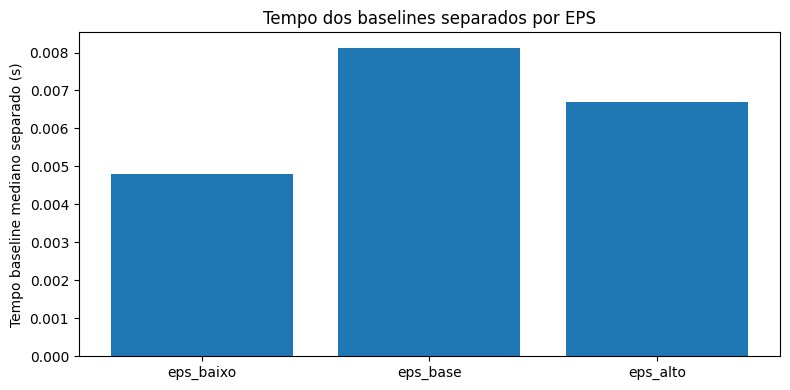

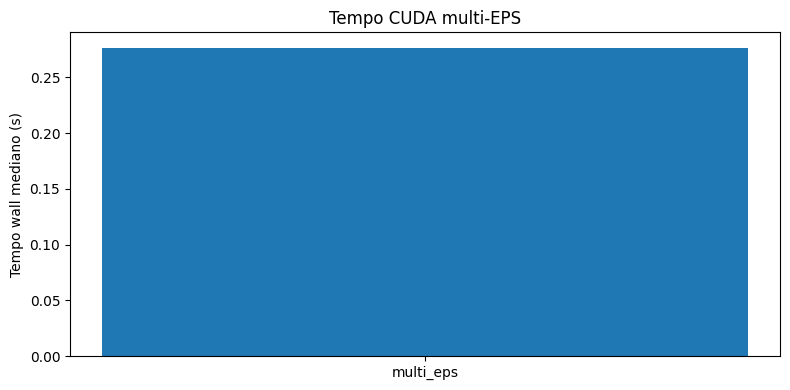

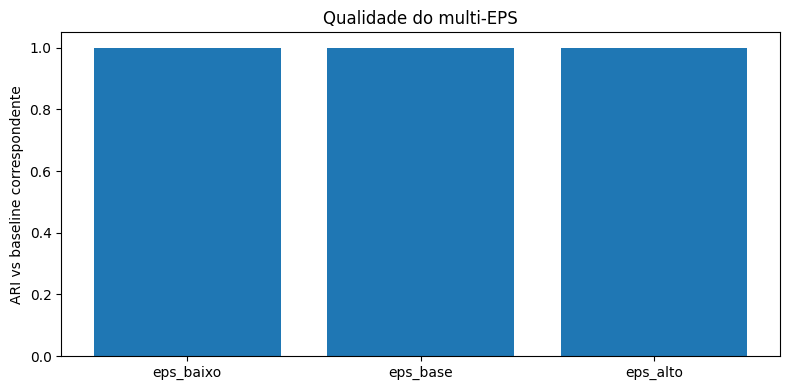

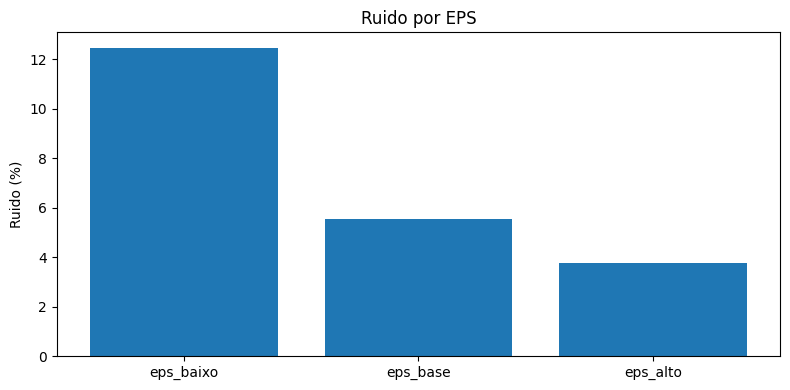

In [10]:
df_plot = df_multi.drop_duplicates("eps_nome")

plt.figure(figsize=(8, 4))
plt.bar(df_plot["eps_nome"], df_plot["tempo_baseline_separado_median_s"])
plt.ylabel("Tempo baseline mediano separado (s)")
plt.title("Tempo dos baselines separados por EPS")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(["multi_eps"], [df_multi["tempo_cuda_multi_eps_median_s"].iloc[0]])
plt.ylabel("Tempo wall mediano (s)")
plt.title("Tempo CUDA multi-EPS")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df_plot["eps_nome"], df_plot["ARI_vs_baseline"])
plt.ylim(0, 1.05)
plt.ylabel("ARI vs baseline correspondente")
plt.title("Qualidade do multi-EPS")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df_plot["eps_nome"], df_plot["ruido_%"])
plt.ylabel("Ruido (%)")
plt.title("Ruido por EPS")
plt.tight_layout()
plt.show()